# GST sweep analysis

Analyze either matched-budget or unmatched seed sweeps using the `RESULTS_MODE` switch. The notebook reports aggregate convergence, individual gate errors, separate state-preparation and measurement errors, and per-gate diamond distance across data seeds.


In [45]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

candidates = [
    Path.cwd(),
    Path.cwd() / "seed_sweep_experiments",
    Path.cwd() / "GST_POUNDERS" / "seed_sweep_experiments",
    Path("/workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments"),
]
EXPERIMENT_DIR = next(
    (p.resolve() for p in candidates if (p / "gst_seed_experiment.py").exists()),
    None,
)
if EXPERIMENT_DIR is None:
    raise FileNotFoundError("Could not locate seed_sweep_experiments.")

RESULTS_MODE = "matched"  # "matched" or "unmatched"
# Use None for the newest top-level results, or a saved experiment group such
# as "geometric_shot_schedule", "lazy_inverse_square", or "lazy_inverse_fourth".
RESULTS_GROUP = None
# None plots every method found in the selected results directory.  To plot
# only one approach, use e.g. ["adaptive_fpr"], ["fixed_fpr"], or
# ["fixed_no_fpr"].  Any subset of the three methods is valid.
METHODS_TO_PLOT = None
PAIRED_SEEDS_ONLY = True
if RESULTS_MODE not in {"matched", "unmatched"}:
    raise ValueError("RESULTS_MODE must be either 'matched' or 'unmatched'.")

BASE_RESULTS_DIR = EXPERIMENT_DIR / (
    "matched_results" if RESULTS_MODE == "matched" else "results"
)
RESULTS_DIR = BASE_RESULTS_DIR / RESULTS_GROUP if RESULTS_GROUP else BASE_RESULTS_DIR
if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results directory does not exist: {RESULTS_DIR}")

REFERENCE = "truth"  # "truth" measures estimator accuracy; "ideal" measures gate error
if REFERENCE not in {"truth", "ideal"}:
    raise ValueError("REFERENCE must be either 'truth' or 'ideal'.")

# Project-specific reporting threshold. This is not a universal GST cutoff.
REPORT_INFIDELITY_TARGET = 1e-4
# Leave as None unless the project defines a task-specific diamond-distance target.
REPORT_DIAMOND_TARGET = None

SAVE_FIGURES = True
FIGURE_DIR = RESULTS_DIR / "figures"
REPORT_TABLE_DIR = RESULTS_DIR / "reporting_tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

STANDARD_METHOD_ORDER = ["adaptive_fpr", "fixed_fpr", "fixed_no_fpr"]
if METHODS_TO_PLOT is None:
    METHOD_ORDER = STANDARD_METHOD_ORDER.copy()
else:
    METHOD_ORDER = list(dict.fromkeys(METHODS_TO_PLOT))
    unknown_methods = [
        method for method in METHOD_ORDER if method not in STANDARD_METHOD_ORDER
    ]
    if not METHOD_ORDER:
        raise ValueError("METHODS_TO_PLOT must contain at least one method.")
    if unknown_methods:
        raise ValueError(
            "Unknown METHODS_TO_PLOT entries: " + ", ".join(unknown_methods)
        )
COLORS = {
    "adaptive_fpr": "#0072B2",
    "fixed_fpr": "#E69F00",
    "fixed_no_fpr": "#009E73",
}
MARKERS = {"adaptive_fpr": "o", "fixed_fpr": "s", "fixed_no_fpr": "^"}

print("Analysis mode:", RESULTS_MODE)
print("Results group:", RESULTS_GROUP or "<top-level>")
print("Results:", RESULTS_DIR)
print("Reference:", REFERENCE)
print("Infidelity target:", REPORT_INFIDELITY_TARGET)
print("Requested methods:", METHODS_TO_PLOT or "<all available>")
print("Paired seeds only:", PAIRED_SEEDS_ONLY)


Analysis mode: matched
Results group: <top-level>
Results: /workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments/matched_results
Reference: truth
Infidelity target: 0.0001
Requested methods: ['fixed_fpr']
Paired seeds only: True


In [46]:

def load_saved_table(filename):
    frames = []
    for path in sorted(RESULTS_DIR.glob(f"seed_*/*/{filename}")):
        if any("calibration" in part for part in path.parts):
            continue
        frame = pd.read_csv(path)
        if frame.empty:
            continue
        seed = int(path.parents[1].name.split("_")[-1])
        method = path.parent.name
        if "method" in frame.columns:
            frame["method"] = method
        else:
            frame.insert(0, "method", method)
        if "data_seed" in frame.columns:
            frame["data_seed"] = seed
        else:
            frame.insert(0, "data_seed", seed)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

iteration_accuracy = load_saved_table("iteration_accuracy.csv")
iteration_gates = load_saved_table("iteration_gate_errors.csv")
iteration_spam = load_saved_table("iteration_spam_errors.csv")
final_gates = load_saved_table("final_gate_errors.csv")
final_spam = load_saved_table("final_spam_errors.csv")
run_summary = load_saved_table("summary.csv")
optimizer_progress = load_saved_table("optimizer_progress.csv")

if iteration_accuracy.empty:
    raise RuntimeError(
        f"No completed runs were found directly below {RESULTS_DIR}. "
        "Check RESULTS_MODE and RESULTS_GROUP."
    )

available_methods = set(iteration_accuracy["method"])
if METHODS_TO_PLOT is None:
    METHOD_ORDER = [
        method for method in STANDARD_METHOD_ORDER if method in available_methods
    ]
else:
    missing_requested_methods = [
        method for method in METHOD_ORDER if method not in available_methods
    ]
    if missing_requested_methods:
        raise RuntimeError(
            "The requested methods have no completed runs: "
            + ", ".join(missing_requested_methods)
        )

if not METHOD_ORDER:
    raise RuntimeError("None of the supported methods has completed-run data.")

USE_PAIRED_SEEDS = PAIRED_SEEDS_ONLY and len(METHOD_ORDER) > 1
seed_sets = {
    method: set(
        iteration_accuracy.loc[
            iteration_accuracy["method"] == method, "data_seed"
        ].astype(int)
    )
    for method in METHOD_ORDER
}
if USE_PAIRED_SEEDS:
    ANALYSIS_SEEDS = sorted(
        set.intersection(*(seed_sets[method] for method in METHOD_ORDER))
    )
else:
    ANALYSIS_SEEDS = sorted(
        set.union(*(seed_sets[method] for method in METHOD_ORDER))
    )
if not ANALYSIS_SEEDS:
    raise RuntimeError("No data seeds are available for the selected methods.")

def keep_analysis_rows(frame):
    if frame.empty:
        return frame
    result = frame
    if "method" in result.columns:
        result = result[result["method"].isin(METHOD_ORDER)]
    if "data_seed" in result.columns:
        result = result[result["data_seed"].astype(int).isin(ANALYSIS_SEEDS)]
    return result.copy()

iteration_accuracy = keep_analysis_rows(iteration_accuracy)
iteration_gates = keep_analysis_rows(iteration_gates)
iteration_spam = keep_analysis_rows(iteration_spam)
final_gates = keep_analysis_rows(final_gates)
final_spam = keep_analysis_rows(final_spam)
run_summary = keep_analysis_rows(run_summary)
optimizer_progress = keep_analysis_rows(optimizer_progress)

finite_diamond_values = (
    pd.to_numeric(final_gates["diamond_distance"], errors="coerce")
    if "diamond_distance" in final_gates.columns
    else pd.Series(dtype=float)
)
print("Completed runs:", iteration_accuracy[["data_seed", "method"]].drop_duplicates().shape[0])
print("Methods plotted:", METHOD_ORDER)
print("Data seeds analyzed:", ANALYSIS_SEEDS)
print("Using paired seeds:", USE_PAIRED_SEEDS)
print("Finite diamond-distance values:", int(np.isfinite(finite_diamond_values).sum()))
if not np.isfinite(finite_diamond_values).any():
    print(
        "WARNING: no finite diamond distances were saved. The other reporting "
        "metrics remain valid, but diamond-distance plots/tables will be empty."
    )

config_records = []
metadata_records = []
for config_path in sorted(RESULTS_DIR.glob("seed_*/*/config.json")):
    if any("calibration" in part for part in config_path.parts):
        continue
    seed = int(config_path.parents[1].name.split("_")[-1])
    if seed not in ANALYSIS_SEEDS:
        continue
    method = config_path.parent.name
    if method not in METHOD_ORDER:
        continue
    payload = json.loads(config_path.read_text(encoding="utf-8"))
    config_records.append({"data_seed": seed, "method": method, **payload})

    metadata_path = config_path.parent / "problem_metadata.json"
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        metadata_records.append({"data_seed": seed, "method": method, **metadata})

experiment_configs = pd.DataFrame(config_records)
problem_metadata = pd.DataFrame(metadata_records)


Completed runs: 1
Methods plotted: ['fixed_fpr']
Data seeds analyzed: [101]
Using paired seeds: False
Finite diamond-distance values: 0



## Reporting-ready summary

These tables separate estimator accuracy, worst-gate behavior, statistical
goodness-of-fit, resource usage, and physicality checks. Values are summarized
across data seeds using medians and interquartile ranges. The infidelity target
is a project-specific benchmark, not a universal GST acceptance threshold.


In [47]:

def finite_series(frame, column):
    if column not in frame.columns:
        return pd.Series(dtype=float)
    values = pd.to_numeric(frame[column], errors="coerce")
    return values[np.isfinite(values)]


def quantiles(frame, column):
    values = finite_series(frame, column)
    if values.empty:
        return (np.nan, np.nan, np.nan)
    return (
        float(values.median()),
        float(values.quantile(0.25)),
        float(values.quantile(0.75)),
    )


def consistent_value(frame, column):
    if frame.empty or column not in frame.columns:
        return np.nan
    values = frame[column].map(
        lambda value: json.dumps(value, sort_keys=True)
        if isinstance(value, (list, dict)) else value
    )
    unique = pd.unique(values.dropna())
    if len(unique) == 0:
        return np.nan
    if len(unique) == 1:
        return unique[0]
    return f"<varies across runs: {len(unique)} values>"


experiment_setup_rows = []
setup_fields = [
    ("model_kind", "GST model kind"),
    ("modelpack_1q", "1Q modelpack"),
    ("modelpack_2q", "2Q modelpack"),
    ("max_lengths", "maximum-length schedule"),
    ("parameterization", "model parameterization"),
    ("objective", "POUNDERS objective"),
    ("variance_source", "WLS variance source"),
    ("variance_floor", "WLS variance floor"),
    ("op_noise", "synthetic operation noise"),
    ("spam_noise", "synthetic SPAM noise"),
    ("sample_error", "sampling model"),
    ("truth_seed", "truth-model seed"),
    ("vary_truth_with_data_seed", "vary truth across data seeds"),
    ("fpr_stage1_method", "FPR stage 1"),
    ("fpr_stage2_method", "FPR stage 2"),
    ("use_fpr_union_mask", "use cumulative FPR union"),
    ("rho_uses_full_objective", "rho uses full objective"),
    ("adaptive_criterion", "adaptive design criterion"),
    ("adaptive_schedule", "adaptive shot schedule"),
    ("adaptive_baseline_shots", "adaptive baseline shots/circuit"),
    ("adaptive_schedule_n0", "adaptive schedule N0"),
    ("adaptive_schedule_base", "adaptive schedule base"),
    ("adaptive_schedule_n_max", "adaptive per-update cap"),
    ("adaptive_total_shot_budget", "adaptive total-shot budget"),
    ("nfmax", "maximum POUNDERS evaluations"),
    ("gtol", "POUNDERS gradient tolerance"),
    ("initial_delta", "initial trust-region radius"),
    ("lower_bound", "parameter lower bound"),
    ("upper_bound", "parameter upper bound"),
    ("pyrol_max_iters", "maximum PyROL inner iterations"),
]
for field, label in setup_fields:
    value = consistent_value(experiment_configs, field)
    if not (isinstance(value, float) and np.isnan(value)):
        experiment_setup_rows.append({"parameter": label, "value": value})

dimension_fields = [
    ("num_parameters", "number of model parameters"),
    ("num_circuits", "number of GST circuits"),
    ("num_residuals", "number of probability residuals"),
    ("outcomes_per_circuit", "outcomes per circuit"),
]
for field, label in dimension_fields:
    value = consistent_value(problem_metadata, field)
    if not (isinstance(value, float) and np.isnan(value)):
        experiment_setup_rows.append({"parameter": label, "value": value})

experiment_setup_rows.extend(
    [
        {"parameter": "analysis data seeds", "value": json.dumps(ANALYSIS_SEEDS)},
        {"parameter": "number of analysis seeds", "value": len(ANALYSIS_SEEDS)},
        {"parameter": "analysis reference", "value": REFERENCE},
        {"parameter": "reporting infidelity target", "value": REPORT_INFIDELITY_TARGET},
    ]
)
experiment_setup_df = pd.DataFrame(experiment_setup_rows)

ent_col = f"mean_gate_entanglement_infidelity_to_{REFERENCE}"
avg_col = f"mean_gate_average_infidelity_to_{REFERENCE}"
spam_col = f"mean_spam_vector_l2_error_to_{REFERENCE}"

reference_gates = final_gates[final_gates["reference"] == REFERENCE].copy()
gate_run_rows = []
for (seed, method), group in reference_gates.groupby(["data_seed", "method"]):
    row = {
        "data_seed": int(seed),
        "method": method,
        "worst_gate_entanglement_infidelity": float(
            pd.to_numeric(group["entanglement_infidelity"], errors="coerce").max()
        ),
    }
    if "diamond_distance" in group.columns:
        diamond_values = finite_series(group, "diamond_distance")
        row["mean_gate_diamond_distance"] = (
            float(diamond_values.mean()) if not diamond_values.empty else np.nan
        )
        row["max_gate_diamond_distance"] = (
            float(diamond_values.max()) if not diamond_values.empty else np.nan
        )
    gate_run_rows.append(row)
gate_run_summary = pd.DataFrame(gate_run_rows)

reference_spam_final = final_spam[final_spam["reference"] == REFERENCE].copy()
spam_run_summary = (
    reference_spam_final.groupby(["data_seed", "method", "member_type"])[
        "vector_l2_error"
    ]
    .mean()
    .unstack("member_type")
    .rename(
        columns={
            "prep": "state_preparation_l2_error",
            "povm_effect": "measurement_effect_l2_error",
        }
    )
    .reset_index()
)

run_level = run_summary.merge(
    gate_run_summary, on=["data_seed", "method"], how="left"
)
run_level = run_level.merge(
    spam_run_summary, on=["data_seed", "method"], how="left"
)
if not optimizer_progress.empty and "nf" in optimizer_progress.columns:
    eval_counts = (
        optimizer_progress.groupby(["data_seed", "method"])["nf"]
        .max()
        .add(1)
        .rename("outer_evaluations")
        .reset_index()
    )
    run_level = run_level.merge(eval_counts, on=["data_seed", "method"], how="left")

accuracy_rows = []
resource_rows = []
for method in METHOD_ORDER:
    group = run_level[run_level["method"] == method].copy()
    if group.empty:
        continue

    ent_med, ent_q25, ent_q75 = quantiles(group, ent_col)
    avg_med, _, _ = quantiles(group, avg_col)
    worst_med, worst_q25, worst_q75 = quantiles(
        group, "worst_gate_entanglement_infidelity"
    )
    diamond_med, diamond_q25, diamond_q75 = quantiles(
        group, "max_gate_diamond_distance"
    )
    spam_med, spam_q25, spam_q75 = quantiles(group, spam_col)
    prep_med, prep_q25, prep_q75 = quantiles(
        group, "state_preparation_l2_error"
    )
    meas_med, meas_q25, meas_q75 = quantiles(
        group, "measurement_effect_l2_error"
    )

    accuracy_rows.append(
        {
            "method": method,
            "num_runs": int(len(group)),
            "mean_entanglement_infidelity_median": ent_med,
            "mean_entanglement_infidelity_q25": ent_q25,
            "mean_entanglement_infidelity_q75": ent_q75,
            "mean_average_gate_infidelity_median": avg_med,
            "worst_gate_entanglement_infidelity_median": worst_med,
            "worst_gate_entanglement_infidelity_q25": worst_q25,
            "worst_gate_entanglement_infidelity_q75": worst_q75,
            "max_gate_diamond_distance_median": diamond_med,
            "max_gate_diamond_distance_q25": diamond_q25,
            "max_gate_diamond_distance_q75": diamond_q75,
            "mean_spam_vector_l2_error_median": spam_med,
            "mean_spam_vector_l2_error_q25": spam_q25,
            "mean_spam_vector_l2_error_q75": spam_q75,
            "state_preparation_l2_error_median": prep_med,
            "state_preparation_l2_error_q25": prep_q25,
            "state_preparation_l2_error_q75": prep_q75,
            "measurement_effect_l2_error_median": meas_med,
            "measurement_effect_l2_error_q25": meas_q25,
            "measurement_effect_l2_error_q75": meas_q75,
            f"fraction_final_infidelity_le_{REPORT_INFIDELITY_TARGET:.0e}": float(
                (finite_series(group, ent_col) <= REPORT_INFIDELITY_TARGET).mean()
            ),
        }
    )

    shots_med, shots_q25, shots_q75 = quantiles(group, "accounted_revealed_shots")
    circuits_med, _, _ = quantiles(group, "revealed_circuits")
    total_circuits_med, _, _ = quantiles(group, "total_circuits")
    redchi_med, redchi_q25, redchi_q75 = quantiles(group, "reduced_chi_square")
    nsigma_med, nsigma_q25, nsigma_q75 = quantiles(group, "n_sigma")
    eval_med, eval_q25, eval_q75 = quantiles(group, "outer_evaluations")

    n_sigma_values = finite_series(group, "n_sigma")
    physical_mask = (
        (pd.to_numeric(group.get("num_probability_below_zero", 0), errors="coerce") == 0)
        & (pd.to_numeric(group.get("num_probability_above_one", 0), errors="coerce") == 0)
    )
    resource_rows.append(
        {
            "method": method,
            "revealed_shots_median": shots_med,
            "revealed_shots_q25": shots_q25,
            "revealed_shots_q75": shots_q75,
            "revealed_circuits_median": circuits_med,
            "revealed_circuit_fraction_median": (
                circuits_med / total_circuits_med
                if np.isfinite(circuits_med)
                and np.isfinite(total_circuits_med)
                and total_circuits_med > 0
                else np.nan
            ),
            "outer_evaluations_median": eval_med,
            "outer_evaluations_q25": eval_q25,
            "outer_evaluations_q75": eval_q75,
            "reduced_chi_square_median": redchi_med,
            "reduced_chi_square_q25": redchi_q25,
            "reduced_chi_square_q75": redchi_q75,
            "n_sigma_median": nsigma_med,
            "n_sigma_q25": nsigma_q25,
            "n_sigma_q75": nsigma_q75,
            "fraction_n_sigma_le_1": (
                float((n_sigma_values <= 1.0).mean())
                if not n_sigma_values.empty else np.nan
            ),
            "fraction_probability_vectors_physical": float(physical_mask.mean()),
        }
    )

accuracy_report_df = pd.DataFrame(accuracy_rows)
resource_fit_report_df = pd.DataFrame(resource_rows)

paired_columns = [
    "method",
    "num_paired_runs",
    "infidelity_ratio_vs_fixed_no_fpr_median",
    "infidelity_ratio_vs_fixed_no_fpr_q25",
    "infidelity_ratio_vs_fixed_no_fpr_q75",
    "shot_ratio_vs_fixed_no_fpr_median",
    "shot_ratio_vs_fixed_no_fpr_q25",
    "shot_ratio_vs_fixed_no_fpr_q75",
]
paired_rows = []
if "fixed_no_fpr" in METHOD_ORDER:
    baseline = run_level[
        run_level["method"] == "fixed_no_fpr"
    ][["data_seed", ent_col, "accounted_revealed_shots"]].rename(
        columns={
            ent_col: "baseline_infidelity",
            "accounted_revealed_shots": "baseline_revealed_shots",
        }
    )
    paired_run_level = run_level.merge(baseline, on="data_seed", how="left")
    paired_run_level["infidelity_ratio_vs_fixed_no_fpr"] = (
        paired_run_level[ent_col] / paired_run_level["baseline_infidelity"]
    )
    paired_run_level["shot_ratio_vs_fixed_no_fpr"] = (
        paired_run_level["accounted_revealed_shots"]
        / paired_run_level["baseline_revealed_shots"]
    )

    for method in METHOD_ORDER:
        group = paired_run_level[paired_run_level["method"] == method]
        if group.empty:
            continue
        inf_ratio_med, inf_ratio_q25, inf_ratio_q75 = quantiles(
            group, "infidelity_ratio_vs_fixed_no_fpr"
        )
        shot_ratio_med, shot_ratio_q25, shot_ratio_q75 = quantiles(
            group, "shot_ratio_vs_fixed_no_fpr"
        )
        paired_rows.append(
            {
                "method": method,
                "num_paired_runs": int(len(group)),
                "infidelity_ratio_vs_fixed_no_fpr_median": inf_ratio_med,
                "infidelity_ratio_vs_fixed_no_fpr_q25": inf_ratio_q25,
                "infidelity_ratio_vs_fixed_no_fpr_q75": inf_ratio_q75,
                "shot_ratio_vs_fixed_no_fpr_median": shot_ratio_med,
                "shot_ratio_vs_fixed_no_fpr_q25": shot_ratio_q25,
                "shot_ratio_vs_fixed_no_fpr_q75": shot_ratio_q75,
            }
        )
else:
    paired_run_level = pd.DataFrame()
    print(
        "Skipping ratios versus fixed_no_fpr because that baseline is not "
        "among METHODS_TO_PLOT."
    )
paired_comparison_report_df = pd.DataFrame(paired_rows, columns=paired_columns)

display(experiment_setup_df)
display(accuracy_report_df)
display(resource_fit_report_df)
display(paired_comparison_report_df)

experiment_setup_df.to_csv(
    REPORT_TABLE_DIR / "experiment_setup.csv", index=False
)
experiment_configs.to_csv(
    REPORT_TABLE_DIR / "experiment_configuration_records.csv", index=False
)
accuracy_report_df.to_csv(
    REPORT_TABLE_DIR / f"accuracy_summary_to_{REFERENCE}.csv", index=False
)
resource_fit_report_df.to_csv(
    REPORT_TABLE_DIR / f"resource_and_fit_summary_to_{REFERENCE}.csv", index=False
)
paired_comparison_report_df.to_csv(
    REPORT_TABLE_DIR / f"paired_comparison_to_{REFERENCE}.csv", index=False
)

gate_metrics = ["entanglement_infidelity", "average_gate_infidelity"]
if "diamond_distance" in reference_gates.columns:
    gate_metrics.append("diamond_distance")
per_gate_report_df = (
    reference_gates.groupby(["method", "gate"])[gate_metrics]
    .agg(["median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), "max"])
)
per_gate_report_df.columns = [
    f"{metric}_{stat}"
    for metric, stat in per_gate_report_df.columns.to_flat_index()
]
per_gate_report_df = per_gate_report_df.rename(
    columns=lambda name: name.replace("<lambda_0>", "q25").replace("<lambda_1>", "q75")
).reset_index()
per_gate_report_df.to_csv(
    REPORT_TABLE_DIR / f"per_gate_summary_to_{REFERENCE}.csv", index=False
)

print("Saved reporting tables to:", REPORT_TABLE_DIR)


Skipping ratios versus fixed_no_fpr because that baseline is not among METHODS_TO_PLOT.


,parameter,value
0,GST model kind,2Q
1,1Q modelpack,smq1Q_XYZI
2,2Q modelpack,smq2Q_XYICNOT
3,maximum-length schedule,"[1, 2, 4, 8, 16, 32, 64]"
4,model parameterization,CPTPLND
5,POUNDERS objective,weighted_least_squares
6,WLS variance source,data
7,WLS variance floor,0.0
8,synthetic operation noise,0.01
9,synthetic SPAM noise,0.005


,method,num_runs,mean_entanglement_infidelity_median,mean_entanglement_infidelity_q25,mean_entanglement_infidelity_q75,mean_average_gate_infidelity_median,worst_gate_entanglement_infidelity_median,worst_gate_entanglement_infidelity_q25,worst_gate_entanglement_infidelity_q75,max_gate_diamond_distance_median,...,mean_spam_vector_l2_error_median,mean_spam_vector_l2_error_q25,mean_spam_vector_l2_error_q75,state_preparation_l2_error_median,state_preparation_l2_error_q25,state_preparation_l2_error_q75,measurement_effect_l2_error_median,measurement_effect_l2_error_q25,measurement_effect_l2_error_q75,fraction_final_infidelity_le_1e-04
0,fixed_fpr,1,0.002867,0.002867,0.002867,0.002294,0.003855,0.003855,0.003855,NaN,...,0.003458,0.003458,0.003458,0.003229,0.003229,0.003229,0.003516,0.003516,0.003516,0.0


,method,revealed_shots_median,revealed_shots_q25,revealed_shots_q75,revealed_circuits_median,revealed_circuit_fraction_median,outer_evaluations_median,outer_evaluations_q25,outer_evaluations_q75,reduced_chi_square_median,reduced_chi_square_q25,reduced_chi_square_q75,n_sigma_median,n_sigma_q25,n_sigma_q75,fraction_n_sigma_le_1,fraction_probability_vectors_physical
0,fixed_fpr,7179000.0,7179000.0,7179000.0,7179.0,0.514329,300.0,300.0,300.0,1.053054,1.053054,1.053054,8.214971,8.214971,8.214971,0.0,1.0


,method,num_paired_runs,infidelity_ratio_vs_fixed_no_fpr_median,infidelity_ratio_vs_fixed_no_fpr_q25,infidelity_ratio_vs_fixed_no_fpr_q75,shot_ratio_vs_fixed_no_fpr_median,shot_ratio_vs_fixed_no_fpr_q25,shot_ratio_vs_fixed_no_fpr_q75


Saved reporting tables to: /workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments/matched_results/reporting_tables



## Final accuracy and goodness-of-fit distributions

The top row reports gate-estimation accuracy. The bottom row reports statistical
fit quality. Diamond distance is summarized by the worst gate in each run,
because a mean can hide a single poorly estimated gate.


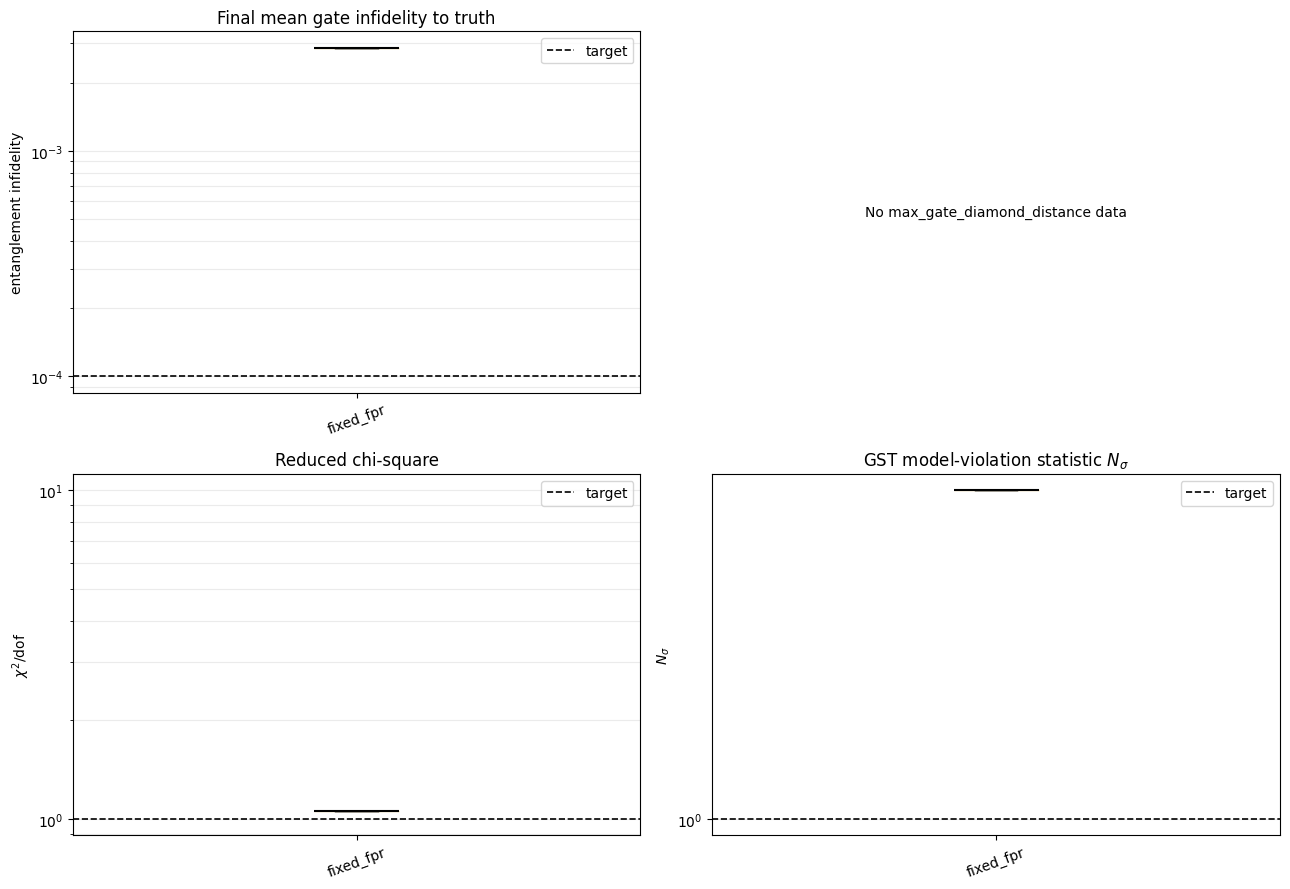

In [48]:

def method_boxplot(axis, frame, column, title, ylabel, log_scale=False, target=None):
    methods = [method for method in METHOD_ORDER if method in set(frame["method"])]
    values = []
    kept_methods = []
    for method in methods:
        current = finite_series(frame[frame["method"] == method], column)
        if current.empty:
            continue
        values.append(current.to_numpy(float))
        kept_methods.append(method)
    if not values:
        axis.text(0.5, 0.5, f"No {column} data", ha="center", va="center")
        axis.set_axis_off()
        return
    boxes = axis.boxplot(values, tick_labels=kept_methods, patch_artist=True, showfliers=True)
    for box, method in zip(boxes["boxes"], kept_methods):
        box.set(facecolor=COLORS[method], edgecolor=COLORS[method], alpha=0.45)
    for median in boxes["medians"]:
        median.set(color="black", linewidth=1.5)
    if log_scale:
        axis.set_yscale("log")
    if target is not None:
        axis.axhline(target, color="black", linestyle="--", linewidth=1.2, label="target")
        axis.legend()
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=20)
    axis.grid(axis="y", alpha=0.25, which="both")


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
method_boxplot(
    axes[0, 0], run_level, ent_col,
    f"Final mean gate infidelity to {REFERENCE}",
    "entanglement infidelity", log_scale=True,
    target=REPORT_INFIDELITY_TARGET,
)
method_boxplot(
    axes[0, 1], run_level, "max_gate_diamond_distance",
    f"Worst-gate diamond distance to {REFERENCE}",
    "maximum gate diamond distance", log_scale=True,
    target=REPORT_DIAMOND_TARGET,
)
method_boxplot(
    axes[1, 0], run_level, "reduced_chi_square",
    "Reduced chi-square",
    r"$\chi^2/\mathrm{dof}$", log_scale=True, target=1.0,
)
method_boxplot(
    axes[1, 1], run_level, "n_sigma",
    r"GST model-violation statistic $N_\sigma$",
    r"$N_\sigma$", log_scale=False, target=1.0,
)
if axes[1, 1].axison:
    axes[1, 1].set_yscale("symlog", linthresh=1.0)

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(
        FIGURE_DIR / f"final_reporting_metrics_to_{REFERENCE}.png",
        dpi=300, bbox_inches="tight",
    )
plt.show()


## Overall infidelity convergence

The line is the median across seeds and the band is the interquartile range.


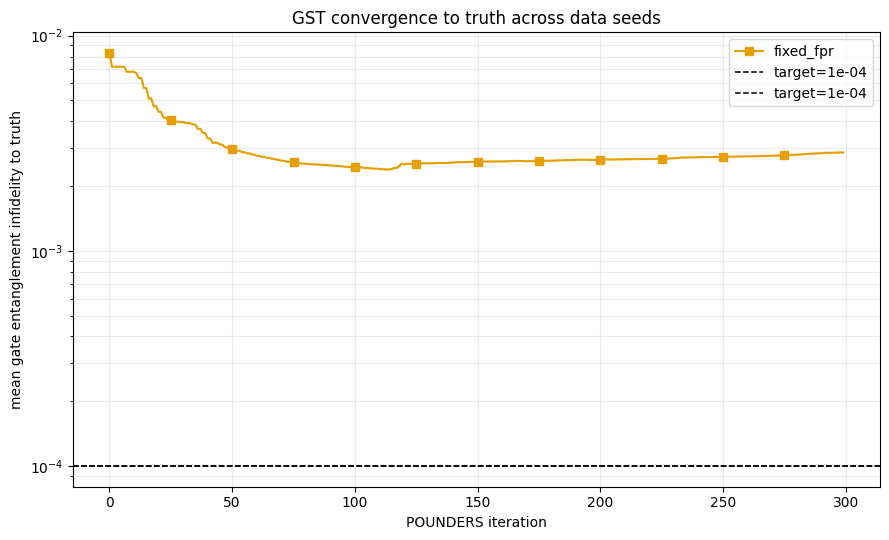

In [49]:
metric = f"mean_gate_entanglement_infidelity_to_{REFERENCE}"
fig, ax = plt.subplots(figsize=(9, 5.5))

for method in METHOD_ORDER:
    part = iteration_accuracy[iteration_accuracy["method"] == method]
    if part.empty or metric not in part:
        continue
    grouped = part.groupby("iteration")[metric]
    x = np.asarray(sorted(grouped.groups), dtype=int)
    median = grouped.median().reindex(x).to_numpy(float)
    q25 = grouped.quantile(0.25).reindex(x).to_numpy(float)
    q75 = grouped.quantile(0.75).reindex(x).to_numpy(float)
    ax.plot(
        x, median, color=COLORS[method], marker=MARKERS[method],
        markevery=max(1, len(x) // 12), label=method,
    )
    ax.fill_between(x, q25, q75, color=COLORS[method], alpha=0.18)

ax.set_yscale("log")
ax.axhline(REPORT_INFIDELITY_TARGET, color="black", linestyle="--", linewidth=1.1, label=f"target={REPORT_INFIDELITY_TARGET:.0e}")
ax.axhline(REPORT_INFIDELITY_TARGET, color="black", linestyle="--", linewidth=1.1, label=f"target={REPORT_INFIDELITY_TARGET:.0e}")
ax.set_xlabel("POUNDERS iteration")
ax.set_ylabel(f"mean gate entanglement infidelity to {REFERENCE}")
ax.set_title(f"GST convergence to {REFERENCE} across data seeds")
ax.grid(alpha=0.25, which="both")
ax.legend()
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR / "infidelity_convergence_across_seeds.png", dpi=300, bbox_inches="tight")
plt.show()


## Individual final gate errors

Each box summarizes the final gate error across data seeds.


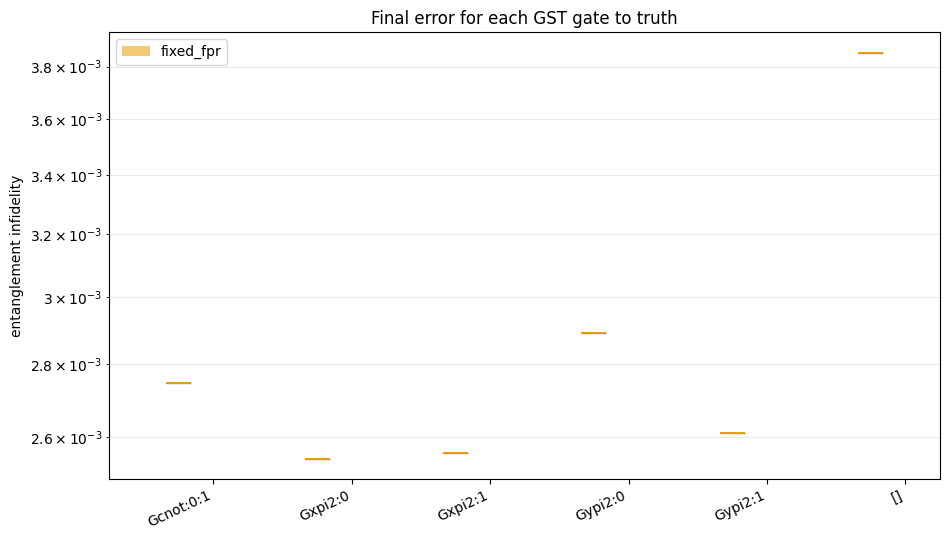

In [50]:
def grouped_boxplot(frame, category, value, title, ylabel, output_name):
    frame = frame[np.isfinite(pd.to_numeric(frame[value], errors="coerce"))].copy()
    categories = sorted(frame[category].astype(str).unique())
    methods = [method for method in METHOD_ORDER if method in set(frame["method"])]
    offsets = np.linspace(-0.25, 0.25, max(1, len(methods)))
    fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(categories)), 5.5))
    for offset, method in zip(offsets, methods):
        for index, label in enumerate(categories):
            values = frame[
                (frame["method"] == method) & (frame[category].astype(str) == label)
            ][value].to_numpy(float)
            if not len(values):
                continue
            box = ax.boxplot(
                values, positions=[index + offset], widths=0.18,
                patch_artist=True, showfliers=True,
            )
            box["boxes"][0].set(facecolor=COLORS[method], alpha=0.45)
            for artist in box["medians"] + box["whiskers"] + box["caps"]:
                artist.set(color=COLORS[method], linewidth=1.4)
    ax.set_xticks(range(len(categories)), categories, rotation=25, ha="right")
    ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25, which="both")
    ax.legend(
        handles=[Patch(facecolor=COLORS[m], alpha=0.55, label=m) for m in methods],
        loc="best",
    )
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / output_name, dpi=300, bbox_inches="tight")
    plt.show()

reference_gates = final_gates[final_gates["reference"] == REFERENCE].copy()
grouped_boxplot(
    reference_gates,
    "gate",
    "entanglement_infidelity",
    f"Final error for each GST gate to {REFERENCE}",
    "entanglement infidelity",
    "individual_gate_infidelity.png",
)


## State-preparation and measurement errors

Preparation and POVM-effect errors are shown separately.


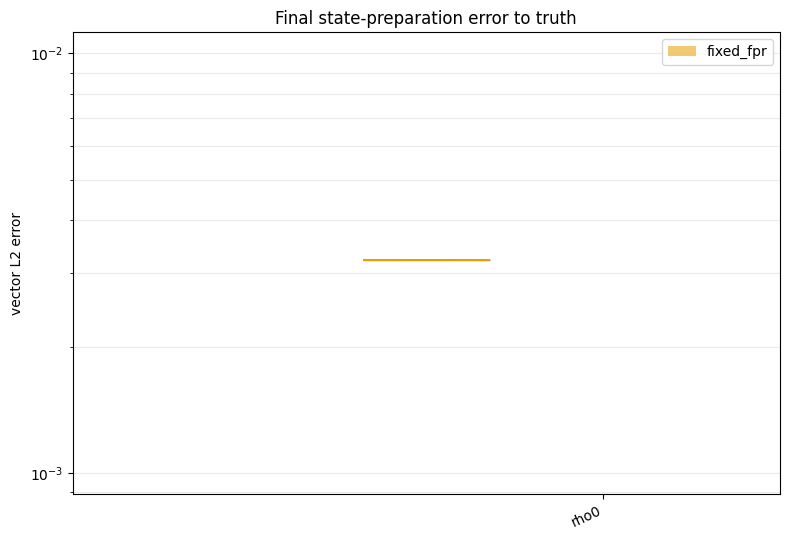

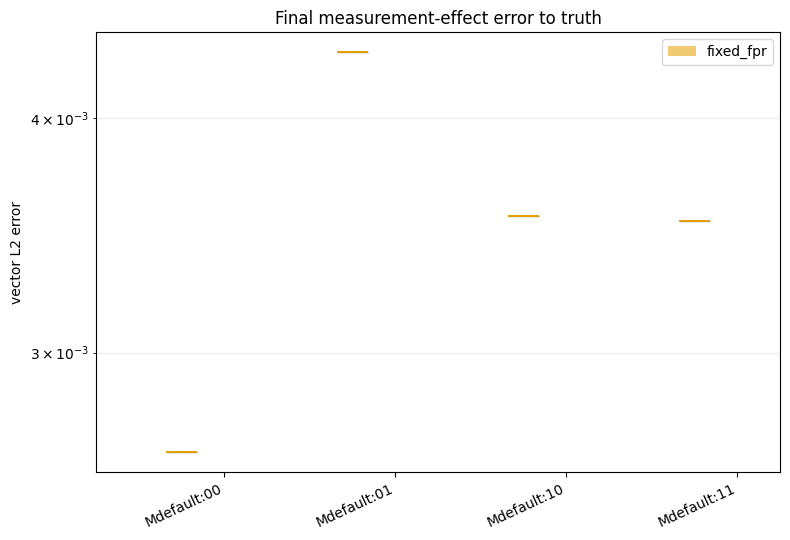

In [51]:
reference_spam = final_spam[final_spam["reference"] == REFERENCE].copy()

prep = reference_spam[reference_spam["member_type"] == "prep"]
measurement = reference_spam[reference_spam["member_type"] == "povm_effect"]

if not prep.empty:
    grouped_boxplot(
        prep, "member", "vector_l2_error",
        f"Final state-preparation error to {REFERENCE}", "vector L2 error",
        "state_preparation_error.png",
    )
if not measurement.empty:
    grouped_boxplot(
        measurement, "member", "vector_l2_error",
        f"Final measurement-effect error to {REFERENCE}", "vector L2 error",
        "measurement_effect_error.png",
    )


## Diamond distance by gate

This plot requires report_diamond_distance=true before running the experiments.


In [38]:
if "diamond_distance" not in reference_gates.columns:
    print(
        "No diamond-distance column was saved. Set report_diamond_distance=true, "
        "set FORCE_RERUN=True, and rerun the experiments."
    )
else:
    diamond = reference_gates[np.isfinite(reference_gates["diamond_distance"])].copy()
    if diamond.empty:
        print("Diamond-distance calculations returned only NaN values.")
    else:
        grouped_boxplot(
            diamond,
            "gate",
            "diamond_distance",
            f"Final diamond distance for each GST gate to {REFERENCE}",
            "diamond distance",
            "individual_gate_diamond_distance.png",
        )


Diamond-distance calculations returned only NaN values.


## SPAM convergence by iteration

These curves show the median state-preparation and measurement error over seeds.


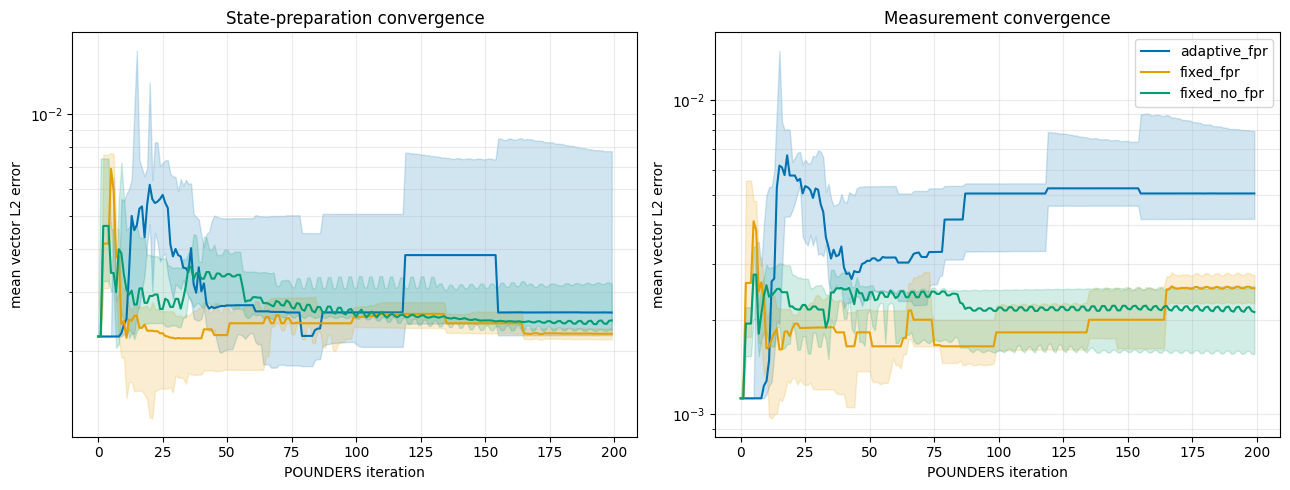

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, member_type, title in [
    (axes[0], "prep", "State-preparation convergence"),
    (axes[1], "povm_effect", "Measurement convergence"),
]:
    subset = iteration_spam[
        (iteration_spam["reference"] == REFERENCE)
        & (iteration_spam["member_type"] == member_type)
    ]
    for method in METHOD_ORDER:
        part = subset[subset["method"] == method]
        if part.empty:
            continue
        seed_iteration = (
            part.groupby(["data_seed", "iteration"])["vector_l2_error"].mean().reset_index()
        )
        grouped = seed_iteration.groupby("iteration")["vector_l2_error"]
        x = np.asarray(sorted(grouped.groups), dtype=int)
        median = grouped.median().reindex(x).to_numpy(float)
        q25 = grouped.quantile(0.25).reindex(x).to_numpy(float)
        q75 = grouped.quantile(0.75).reindex(x).to_numpy(float)
        ax.plot(x, median, color=COLORS[method], label=method)
        ax.fill_between(x, q25, q75, color=COLORS[method], alpha=0.18)
    ax.set_yscale("log")
    ax.set_xlabel("POUNDERS iteration")
    ax.set_ylabel("mean vector L2 error")
    ax.set_title(title)
    ax.grid(alpha=0.25, which="both")
axes[1].legend()
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR / "spam_convergence_across_seeds.png", dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_24/4084515408.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax_final.boxplot(values, labels=methods, patch_artist=True, showfliers=True)


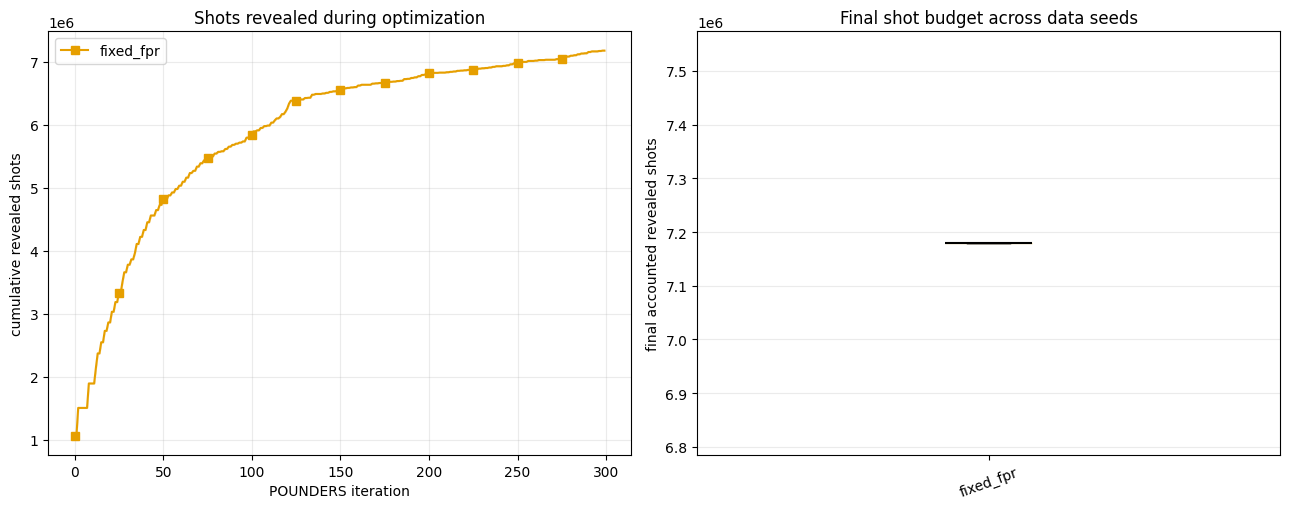

In [52]:
def load_revealed_shot_progress():
    frames = []
    for run_dir in sorted(RESULTS_DIR.glob("seed_*/*")):
        if not run_dir.is_dir() or any("calibration" in part for part in run_dir.parts):
            continue

        seed = int(run_dir.parent.name.split("_")[-1])
        if seed not in ANALYSIS_SEEDS:
            continue
        method = run_dir.name

        if method == "adaptive_fpr":
            path = run_dir / "adaptive_shot_events.csv"
            if not path.exists() or path.stat().st_size == 0:
                continue
            frame = pd.read_csv(path)
            if frame.empty or "accounted_revealed_shots" not in frame:
                continue
            frame = frame[["iteration", "accounted_revealed_shots"]].copy()
            frame = frame.rename(columns={"accounted_revealed_shots": "revealed_shots"})
        else:
            path = run_dir / "optimizer_progress.csv"
            if not path.exists() or path.stat().st_size == 0:
                continue
            frame = pd.read_csv(path)
            if frame.empty or "cumulative_shots_revealed" not in frame:
                continue
            frame = (
                frame.groupby("nf", as_index=False)["cumulative_shots_revealed"]
                .last()
                .rename(columns={"nf": "iteration", "cumulative_shots_revealed": "revealed_shots"})
            )

        frame.insert(0, "method", method)
        frame.insert(0, "data_seed", seed)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


shot_progress = load_revealed_shot_progress()
final_shots = load_saved_table("summary.csv")

fig, (ax_trace, ax_final) = plt.subplots(1, 2, figsize=(13, 5.2))

# Cumulative revealed-shot trace. Forward-filling keeps completed runs in the
# across-seed summary instead of silently dropping them at later iterations.
for method in METHOD_ORDER:
    part = shot_progress[shot_progress["method"] == method]
    if part.empty:
        continue
    pivot = part.pivot_table(
        index="iteration", columns="data_seed", values="revealed_shots", aggfunc="last"
    ).sort_index()
    full_iterations = np.arange(int(pivot.index.min()), int(pivot.index.max()) + 1)
    pivot = pivot.reindex(full_iterations).ffill()
    median = pivot.median(axis=1).to_numpy(float)
    q25 = pivot.quantile(0.25, axis=1).to_numpy(float)
    q75 = pivot.quantile(0.75, axis=1).to_numpy(float)
    ax_trace.plot(
        full_iterations,
        median,
        color=COLORS[method],
        marker=MARKERS[method],
        markevery=max(1, len(full_iterations) // 12),
        label=method,
    )
    ax_trace.fill_between(full_iterations, q25, q75, color=COLORS[method], alpha=0.18)

ax_trace.set_xlabel("POUNDERS iteration")
ax_trace.set_ylabel("cumulative revealed shots")
ax_trace.set_title("Shots revealed during optimization")
ax_trace.grid(alpha=0.25)
ax_trace.legend()

# Final accounted budget distribution across seeds.
methods = [m for m in METHOD_ORDER if m in set(final_shots.get("method", []))]
values = [
    final_shots.loc[final_shots["method"] == method, "accounted_revealed_shots"].to_numpy(float)
    for method in methods
]
boxes = ax_final.boxplot(values, labels=methods, patch_artist=True, showfliers=True)
for box, method in zip(boxes["boxes"], methods):
    box.set(facecolor=COLORS[method], edgecolor=COLORS[method], alpha=0.45)
for median in boxes["medians"]:
    median.set(color="black", linewidth=1.5)
ax_final.set_ylabel("final accounted revealed shots")
ax_final.set_title("Final shot budget across data seeds")
ax_final.tick_params(axis="x", rotation=20)
ax_final.grid(axis="y", alpha=0.25)

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR / "revealed_shots_across_seeds.png", dpi=300, bbox_inches="tight")
plt.show()


## Infidelity versus revealed shots

This shot-efficiency plot pairs each incumbent accuracy measurement with the cumulative number of shots revealed by that point. The line is the median across data seeds and the band is the interquartile range of infidelity.


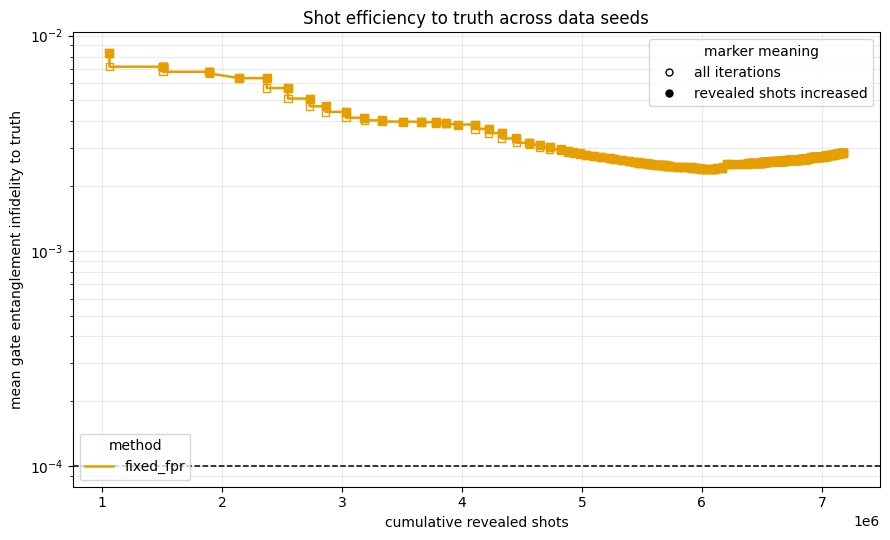

In [53]:
metric = f"mean_gate_entanglement_infidelity_to_{REFERENCE}"
efficiency_frames = []

# Match each accuracy record to the revealed-shot total at the same iteration.
# Forward filling is needed when a run optimizes without acquiring new shots.
for (seed, method), accuracy in iteration_accuracy.groupby(["data_seed", "method"]):
    shots = shot_progress[
        (shot_progress["data_seed"] == seed)
        & (shot_progress["method"] == method)
    ]
    if shots.empty or metric not in accuracy.columns:
        continue

    accuracy = (
        accuracy[["iteration", metric]]
        .drop_duplicates("iteration", keep="last")
        .sort_values("iteration")
        .set_index("iteration")
    )
    revealed = (
        shots.groupby("iteration")["revealed_shots"]
        .last()
        .sort_index()
        .reindex(accuracy.index)
        .ffill()
        .bfill()
    )
    matched = accuracy.assign(
        revealed_shots=revealed, data_seed=seed, method=method
    ).reset_index()
    efficiency_frames.append(matched)

shot_efficiency = (
    pd.concat(efficiency_frames, ignore_index=True)
    if efficiency_frames else pd.DataFrame()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
for method in METHOD_ORDER:
    part = shot_efficiency[shot_efficiency["method"] == method].copy()
    part = part[
        np.isfinite(part["revealed_shots"])
        & np.isfinite(part[metric])
        & (part["revealed_shots"] > 0)
        & (part[metric] > 0)
    ]
    if part.empty:
        continue

    # Keep every seed in the summary after it terminates. Without this
    # forward-fill, the set of seeds defining the median changes over time and
    # can make a cumulative-shot curve appear to move backward.
    full_iterations = np.arange(
        int(part["iteration"].min()), int(part["iteration"].max()) + 1
    )
    shots_by_seed = (
        part.pivot_table(
            index="iteration",
            columns="data_seed",
            values="revealed_shots",
            aggfunc="last",
        )
        .reindex(full_iterations)
        .ffill()
    )
    infidelity_by_seed = (
        part.pivot_table(
            index="iteration",
            columns="data_seed",
            values=metric,
            aggfunc="last",
        )
        .reindex(full_iterations)
        .ffill()
    )
    common_seeds = shots_by_seed.columns.intersection(infidelity_by_seed.columns)
    shots_by_seed = shots_by_seed[common_seeds]
    infidelity_by_seed = infidelity_by_seed[common_seeds]

    decreasing = shots_by_seed.diff().lt(0).any()
    if decreasing.any():
        bad_seeds = [int(seed) for seed in decreasing[decreasing].index]
        raise ValueError(
            f"Cumulative revealed shots decreased for {method}, seeds={bad_seeds}."
        )

    median_shots = shots_by_seed.median(axis=1).to_numpy(float)
    median_infid = infidelity_by_seed.median(axis=1).to_numpy(float)
    q25_infid = infidelity_by_seed.quantile(0.25, axis=1).to_numpy(float)
    q75_infid = infidelity_by_seed.quantile(0.75, axis=1).to_numpy(float)

    ax.plot(
        median_shots, median_infid,
        color=COLORS[method], linewidth=1.8, label=method,
    )
    # Every iteration is hollow. A filled marker means the median revealed-shot
    # total increased at this iteration; the first point is the initial acquisition.
    ax.scatter(
        median_shots, median_infid, s=28, marker=MARKERS[method],
        facecolors="none", edgecolors=COLORS[method], linewidths=1.0, zorder=3,
    )
    shot_added = np.r_[True, np.diff(median_shots) > 0]
    ax.scatter(
        median_shots[shot_added], median_infid[shot_added],
        s=28, marker=MARKERS[method], color=COLORS[method],
        edgecolors=COLORS[method], linewidths=1.0, zorder=4,
    )
    ax.fill_between(
        median_shots, q25_infid, q75_infid,
        color=COLORS[method], alpha=0.18,
    )

ax.axhline(REPORT_INFIDELITY_TARGET, color="black", linestyle="--", linewidth=1.1)
ax.set_xscale("linear")
ax.set_yscale("log")
ax.set_xlabel("cumulative revealed shots")
ax.set_ylabel(f"mean gate entanglement infidelity to {REFERENCE}")
ax.set_title(f"Shot efficiency to {REFERENCE} across data seeds")
ax.grid(alpha=0.25, which="both")
method_legend = ax.legend(loc="lower left", title="method")
ax.add_artist(method_legend)
from matplotlib.lines import Line2D
marker_legend = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=5,
           markerfacecolor="white", markeredgecolor="black", label="all iterations"),
    Line2D([0], [0], marker="o", linestyle="none", markersize=5,
           markerfacecolor="black", markeredgecolor="black", label="revealed shots increased"),
]
ax.legend(handles=marker_legend, loc="upper right", title="marker meaning")
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR / "infidelity_vs_revealed_shots.png", dpi=300, bbox_inches="tight")
plt.show()



## Accuracy-target efficiency

This table reports both whether a run ever reached the project-specific
infidelity target and whether it remained below that target at termination.
Because POUNDERS traces may be nonmonotone, these are intentionally separate.


In [42]:

target_run_rows = []
for (seed, method), group in shot_efficiency.groupby(["data_seed", "method"]):
    group = group.sort_values("iteration")
    valid = group[
        np.isfinite(group[metric])
        & np.isfinite(group["revealed_shots"])
        & (group["revealed_shots"] > 0)
    ].copy()
    if valid.empty:
        continue
    hits = valid[valid[metric] <= REPORT_INFIDELITY_TARGET]
    first_hit = hits.iloc[0] if not hits.empty else None
    final = valid.iloc[-1]
    target_run_rows.append(
        {
            "data_seed": int(seed),
            "method": method,
            "ever_reached_target": bool(not hits.empty),
            "finished_below_target": bool(final[metric] <= REPORT_INFIDELITY_TARGET),
            "first_target_iteration": (
                int(first_hit["iteration"]) if first_hit is not None else np.nan
            ),
            "shots_at_first_target": (
                float(first_hit["revealed_shots"]) if first_hit is not None else np.nan
            ),
            "best_infidelity": float(valid[metric].min()),
            "final_infidelity": float(final[metric]),
            "final_revealed_shots": float(final["revealed_shots"]),
        }
    )

target_run_df = pd.DataFrame(target_run_rows)
target_summary_rows = []
for method in METHOD_ORDER:
    group = target_run_df[target_run_df["method"] == method]
    if group.empty:
        continue
    successful_shots = finite_series(
        group[group["ever_reached_target"]], "shots_at_first_target"
    )
    target_summary_rows.append(
        {
            "method": method,
            "num_runs": int(len(group)),
            "fraction_ever_reached_target": float(group["ever_reached_target"].mean()),
            "fraction_finished_below_target": float(group["finished_below_target"].mean()),
            "median_shots_at_first_target_among_successes": (
                float(successful_shots.median()) if not successful_shots.empty else np.nan
            ),
            "median_best_infidelity": float(group["best_infidelity"].median()),
            "median_final_infidelity": float(group["final_infidelity"].median()),
            "median_final_revealed_shots": float(group["final_revealed_shots"].median()),
        }
    )

target_efficiency_report_df = pd.DataFrame(target_summary_rows)
display(target_efficiency_report_df)
target_run_df.to_csv(
    REPORT_TABLE_DIR / f"target_runs_{REPORT_INFIDELITY_TARGET:.0e}.csv", index=False
)
target_efficiency_report_df.to_csv(
    REPORT_TABLE_DIR / f"target_efficiency_{REPORT_INFIDELITY_TARGET:.0e}.csv",
    index=False,
)


,method,num_runs,fraction_ever_reached_target,fraction_finished_below_target,median_shots_at_first_target_among_successes,median_best_infidelity,median_final_infidelity,median_final_revealed_shots
0,adaptive_fpr,10,0.8,0.6,843150.0,0.000064,0.000083,858600.0
1,fixed_fpr,10,0.5,0.5,816000.0,0.000092,0.000092,855000.0
2,fixed_no_fpr,10,0.7,0.7,853510.0,0.000081,0.000081,853510.0
